In [19]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Import classifiers
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# 1. Load and prepare data
iris = load_iris()
X = iris.data
y = iris.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Create a dictionary of models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM (Linear)": SVC(kernel='linear', random_state=42),
    "Naive Bayes": GaussianNB()
}

# --- ADDED THIS LINE ---
trained_models = [] # Add a list to store trained models
# -----------------------

# 3. Loop through models to train, predict, and evaluate
for name, model in models.items():
    print(f"--- {name} ---")

    # Train the model
    model.fit(X_train, y_train)

    # --- ADDED THIS LINE ---
    trained_models.append(model) # Store the trained model
    # -----------------------

    # Make predictions
    y_pred = model.predict(X_test)

    # Show results
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

    # Show classification report (Accuracy, Precision, Recall, F-score)
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=iris.target_names))

    # Show confusion matrix
    print("Confusion Matrix:")
    print(pd.DataFrame(confusion_matrix(y_test, y_pred),
                       index=iris.target_names,
                       columns=iris.target_names))
    print("\n" + "="*70 + "\n")

# You can now access your trained models, e.g.:
# print(trained_models[0]) # This would be the trained Decision Tree
# print(trained_models[1]) # This would be the trained Random Forest

--- Decision Tree ---
Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

Confusion Matrix:
            setosa  versicolor  virginica
setosa          19           0          0
versicolor       0          13          0
virginica        0           0         13


--- Random Forest ---
Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00  

In [2]:
# You MUST run this line in Colab first to install the library
!pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 6.8 MB/s eta 0:00:00


In [16]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from hmmlearn import hmm

# --- 1. GaussianHMM ---
print("--- GaussianHMM ---")

# Load and split data
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# HMMs are sensitive to scale, so we scale the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train one HMM per class (0 = malignant, 1 = benign)
hmm_class_0 = hmm.GaussianHMM(n_components=4, covariance_type="diag", n_iter=100, random_state=42)
hmm_class_1 = hmm.GaussianHMM(n_components=4, covariance_type="diag", n_iter=100, random_state=42)

# Fit models on data from their respective class
hmm_class_0.fit(X_train[y_train == 0])
hmm_class_1.fit(X_train[y_train == 1])

# Make predictions on the test set
y_pred = []
for i in range(len(X_test)):
    # Reshape for a single sample. HMMs expect 2D data.
    sample = X_test[i].reshape(1, -1)

    # Calculate log-likelihood score from each model
    score_0 = hmm_class_0.score(sample)
    score_1 = hmm_class_1.score(sample)

    # The class with the higher score wins
    y_pred.append(1 if score_1 > score_0 else 0)

# Evaluate GaussianHMM
print("GaussianHMM Classification Report:")
print(classification_report(y_test, y_pred, target_names=cancer.target_names))
print("\n" + "="*70 + "\n")


# --- 2. MultinomialHMM ---
print("--- MultinomialHMM ---")
# MultinomialHMM requires discrete data (counts/categories), not continuous.
# We must first "discretize" the data.
discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')
X_train_discrete = discretizer.fit_transform(X_train).astype(int)
X_test_discrete = discretizer.transform(X_test).astype(int)

# Train one HMM per class
hmm_multi_0 = hmm.MultinomialHMM(n_components=4, n_iter=100, random_state=42)
hmm_multi_1 = hmm.MultinomialHMM(n_components=4, n_iter=100, random_state=42)

# Fit models on data from their respective class
hmm_multi_0.fit(X_train_discrete[y_train == 0])
hmm_multi_1.fit(X_train_discrete[y_train == 1])

# Make predictions
y_pred_multi = []
for i in range(len(X_test_discrete)):
    sample = X_test_discrete[i].reshape(1, -1)

    # Calculate log-likelihood score from each model
    score_0 = hmm_multi_0.score(sample)
    score_1 = hmm_multi_1.score(sample)

    # The class with the higher score wins
    y_pred_multi.append(1 if score_1 > score_0 else 0)

# Evaluate MultinomialHMM
print("MultinomialHMM Classification Report:")
print(classification_report(y_test, y_pred_multi, target_names=cancer.target_names))
print("\n" + "="*70 + "\n")

--- GaussianHMM ---


https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340


GaussianHMM Classification Report:
              precision    recall  f1-score   support

   malignant       0.59      1.00      0.74        63
      benign       1.00      0.59      0.74       108

    accuracy                           0.74       171
   macro avg       0.79      0.80      0.74       171
weighted avg       0.85      0.74      0.74       171



--- MultinomialHMM ---
MultinomialHMM Classification Report:
              precision    recall  f1-score   support

   malignant       0.72      0.33      0.46        63
      benign       0.70      0.93      0.80       108

    accuracy                           0.71       171
   macro avg       0.71      0.63      0.63       171
weighted avg       0.71      0.71      0.67       171





--- GaussianHMM (Untuned, n_components=4) ---
GaussianHMM (Untuned) Classification Report:
              precision    recall  f1-score   support

   malignant       0.59      1.00      0.74        63
      benign       1.00      0.59      0.74       108

    accuracy                           0.74       171
   macro avg       0.79      0.80      0.74       171
weighted avg       0.85      0.74      0.74       171

Untuned GaussianHMM AUC: 0.9746


--- GaussianHMM (Tuned, n_components=8) ---
GaussianHMM (Tuned) Classification Report:
              precision    recall  f1-score   support

   malignant       0.43      1.00      0.60        63
      benign       1.00      0.21      0.35       108

    accuracy                           0.50       171
   macro avg       0.71      0.61      0.47       171
weighted avg       0.79      0.50      0.44       171

Tuned GaussianHMM AUC: 0.9417




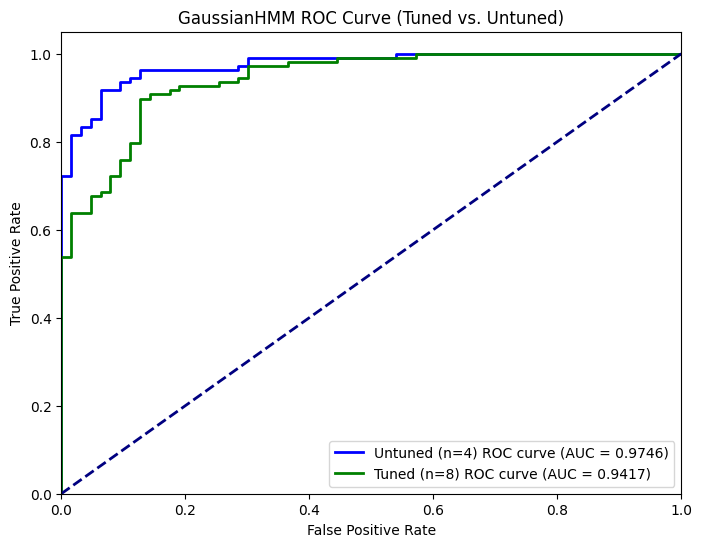

https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340


--- MultinomialHMM ---
MultinomialHMM Classification Report:
              precision    recall  f1-score   support

   malignant       0.72      0.33      0.46        63
      benign       0.70      0.93      0.80       108

    accuracy                           0.71       171
   macro avg       0.71      0.63      0.63       171
weighted avg       0.71      0.71      0.67       171

MultinomialHMM AUC: 0.8892




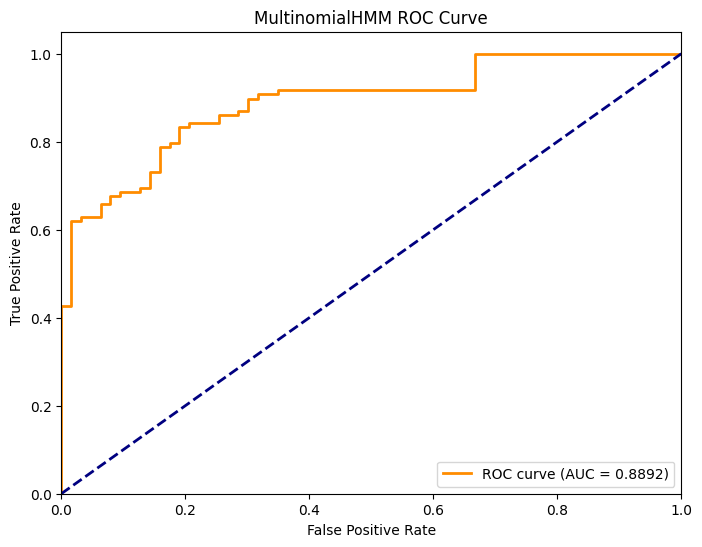

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from hmmlearn import hmm

# --- 1a. GaussianHMM (Without Tuning) ---
print("--- GaussianHMM (Untuned, n_components=4) ---")

# Load and split data
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# HMMs are sensitive to scale, so we scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train one HMM per class (0 = malignant, 1 = benign)
hmm_class_0 = hmm.GaussianHMM(n_components=4, covariance_type="diag", n_iter=100, random_state=42)
hmm_class_1 = hmm.GaussianHMM(n_components=4, covariance_type="diag", n_iter=100, random_state=42)

# Fit models on data from their respective class
hmm_class_0.fit(X_train_scaled[y_train == 0])
hmm_class_1.fit(X_train_scaled[y_train == 1])

# Make predictions on the test set
y_pred = []
y_scores_g_untuned = [] # Store scores for ROC curve
for i in range(len(X_test_scaled)):
    sample = X_test_scaled[i].reshape(1, -1)

    score_0 = hmm_class_0.score(sample)
    score_1 = hmm_class_1.score(sample)

    # The class with the higher score wins
    y_pred.append(1 if score_1 > score_0 else 0)
    # The score *difference* is used to build the ROC curve
    y_scores_g_untuned.append(score_1 - score_0)

# Evaluate GaussianHMM
print("GaussianHMM (Untuned) Classification Report:")
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

# --- FIX START: Clean up infinity values ---
y_scores_g_untuned = np.array(y_scores_g_untuned)
y_scores_g_untuned[y_scores_g_untuned == np.inf] = np.finfo(y_scores_g_untuned.dtype).max
y_scores_g_untuned[y_scores_g_untuned == -np.inf] = np.finfo(y_scores_g_untuned.dtype).min
# --- FIX END ---

# Calculate ROC/AUC for untuned GaussianHMM
fpr_g_untuned, tpr_g_untuned, _ = roc_curve(y_test, y_scores_g_untuned)
roc_auc_g_untuned = auc(fpr_g_untuned, tpr_g_untuned)
print(f"Untuned GaussianHMM AUC: {roc_auc_g_untuned:.4f}")
print("\n" + "="*70 + "\n")


# --- 1b. GaussianHMM (With Tuning) ---
print("--- GaussianHMM (Tuned, n_components=8) ---")
# "Tuning" here means we try a different parameter, e.g., n_components=8
tuned_n_components = 8

hmm_class_0_tuned = hmm.GaussianHMM(n_components=tuned_n_components, covariance_type="diag", n_iter=100, random_state=42)
hmm_class_1_tuned = hmm.GaussianHMM(n_components=tuned_n_components, covariance_type="diag", n_iter=100, random_state=42)

hmm_class_0_tuned.fit(X_train_scaled[y_train == 0])
hmm_class_1_tuned.fit(X_train_scaled[y_train == 1])

# Make predictions with the tuned model
y_pred_tuned = []
y_scores_g_tuned = [] # Store scores for tuned ROC curve
for i in range(len(X_test_scaled)):
    sample = X_test_scaled[i].reshape(1, -1)

    score_0 = hmm_class_0_tuned.score(sample)
    score_1 = hmm_class_1_tuned.score(sample)

    y_pred_tuned.append(1 if score_1 > score_0 else 0)
    y_scores_g_tuned.append(score_1 - score_0)

# Evaluate Tuned GaussianHMM
print("GaussianHMM (Tuned) Classification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=cancer.target_names))

# --- FIX START: Clean up infinity values ---
y_scores_g_tuned = np.array(y_scores_g_tuned)
y_scores_g_tuned[y_scores_g_tuned == np.inf] = np.finfo(y_scores_g_tuned.dtype).max
y_scores_g_tuned[y_scores_g_tuned == -np.inf] = np.finfo(y_scores_g_tuned.dtype).min
# --- FIX END ---

# Calculate ROC/AUC for tuned GaussianHMM
fpr_g_tuned, tpr_g_tuned, _ = roc_curve(y_test, y_scores_g_tuned)
roc_auc_g_tuned = auc(fpr_g_tuned, tpr_g_tuned)
print(f"Tuned GaussianHMM AUC: {roc_auc_g_tuned:.4f}")
print("\n" + "="*70 + "\n")


# --- Plot GaussianHMM ROC Curve Comparison ---
plt.figure(figsize=(8, 6))
plt.plot(fpr_g_untuned, tpr_g_untuned, color='blue', lw=2,
         label=f'Untuned (n=4) ROC curve (AUC = {roc_auc_g_untuned:.4f})')
plt.plot(fpr_g_tuned, tpr_g_tuned, color='green', lw=2,
         label=f'Tuned (n=8) ROC curve (AUC = {roc_auc_g_tuned:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('GaussianHMM ROC Curve (Tuned vs. Untuned)')
plt.legend(loc="lower right")
plt.show()


# --- 2. MultinomialHMM ---
print("--- MultinomialHMM ---")
# MultinomialHMM requires discrete data (counts/categories), not continuous.
# We must first "discretize" the data.
discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')
# Note: We discretize the ORIGINAL data, not the scaled data
X_train_discrete = discretizer.fit_transform(X_train).astype(int)
X_test_discrete = discretizer.transform(X_test).astype(int)

# Train one HMM per class
hmm_multi_0 = hmm.MultinomialHMM(n_components=4, n_iter=100, random_state=42)
hmm_multi_1 = hmm.MultinomialHMM(n_components=4, n_iter=100, random_state=42)

hmm_multi_0.fit(X_train_discrete[y_train == 0])
hmm_multi_1.fit(X_train_discrete[y_train == 1])

# Make predictions
y_pred_multi = []
y_scores_multi = [] # Store scores for ROC curve
for i in range(len(X_test_discrete)):
    sample = X_test_discrete[i].reshape(1, -1)

    score_0 = hmm_multi_0.score(sample)
    score_1 = hmm_multi_1.score(sample)

    y_pred_multi.append(1 if score_1 > score_0 else 0)
    y_scores_multi.append(score_1 - score_0)

# Evaluate MultinomialHMM
print("MultinomialHMM Classification Report:")
print(classification_report(y_test, y_pred_multi, target_names=cancer.target_names))

# --- FIX START: Clean up infinity values ---
y_scores_multi = np.array(y_scores_multi)
y_scores_multi[y_scores_multi == np.inf] = np.finfo(y_scores_multi.dtype).max
y_scores_multi[y_scores_multi == -np.inf] = np.finfo(y_scores_multi.dtype).min
# --- FIX END ---

# Calculate ROC/AUC for MultinomialHMM
fpr_m, tpr_m, _ = roc_curve(y_test, y_scores_multi)
roc_auc_m = auc(fpr_m, tpr_m)
print(f"MultinomialHMM AUC: {roc_auc_m:.4f}")
print("\n" + "="*70 + "\n")

# --- Plot MultinomialHMM ROC Curve ---
plt.figure(figsize=(8, 6))
plt.plot(fpr_m, tpr_m, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc_m:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('MultinomialHMM ROC Curve')
plt.legend(loc="lower right")
plt.show()

--- K-means ---
K-means Silhouette Score: 0.2849
K-means Adjusted Rand Score: 0.8975


--- DBSCAN ---
DBSCAN labels found: 3
DBSCAN Silhouette Score: 0.1343
DBSCAN Adjusted Rand Score: -0.0066


--- Hierarchical Clustering (Dendrogram) ---


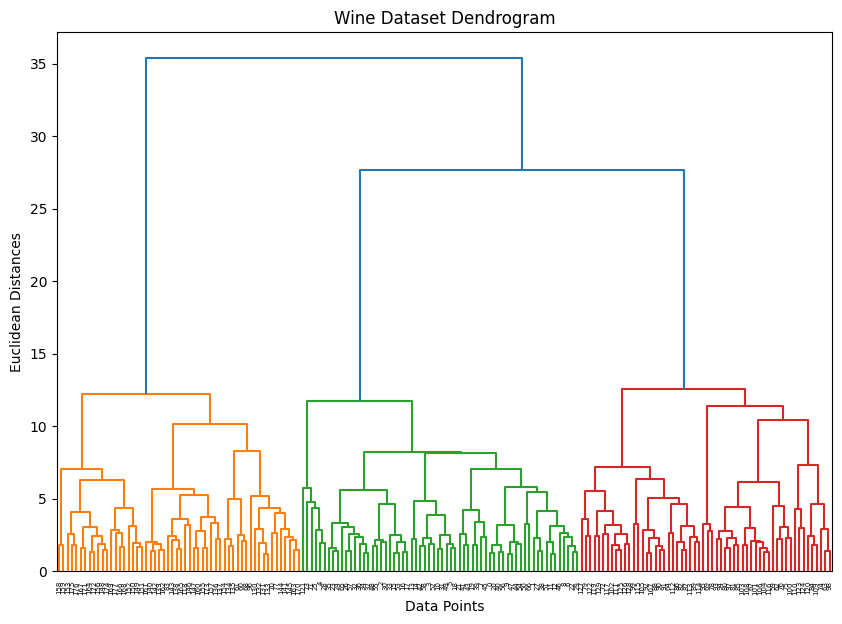

Hierarchical Silhouette Score: 0.2774
Hierarchical Adjusted Rand Score: 0.7899


--- Performance Metric Comparison ---
| Model        |   Silhouette (Higher=Better) |   Calinski-Harabasz (Higher=Better) |   Davies-Bouldin (Lower=Better) |   Adj. Rand Score (vs True) |
|:-------------|-----------------------------:|------------------------------------:|--------------------------------:|----------------------------:|
| K-means      |                       0.2849 |                             70.9400 |                          1.3892 |                      0.8975 |
| DBSCAN       |                       0.1343 |                              4.0665 |                          2.2708 |                     -0.0066 |
| Hierarchical |                       0.2774 |                             67.6475 |                          1.4186 |                      0.7899 |


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# For the Dendrogram
import scipy.cluster.hierarchy as sch

# 1. Load and prepare data
wine = load_wine()
X = wine.data
y = wine.target_names # Store names for later
true_labels = wine.target

# IMPORTANT: For clustering, especially DBSCAN, scaling is critical.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 2. K-means ---
print("--- K-means ---")
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # 3 classes in wine dataset
kmeans_labels = kmeans.fit_predict(X_scaled)
print(f"K-means Silhouette Score: {silhouette_score(X_scaled, kmeans_labels):.4f}")
print(f"K-means Adjusted Rand Score: {adjusted_rand_score(true_labels, kmeans_labels):.4f}")
print("\n")

# --- 3. DBSCAN ---
# DBSCAN's parameters (eps, min_samples) need tuning. These are just examples.
print("--- DBSCAN ---")
dbscan = DBSCAN(eps=3, min_samples=2)
dbscan_labels = dbscan.fit_predict(X_scaled)
# Note: DBSCAN may find different number of clusters. -1 = noise.
print(f"DBSCAN labels found: {len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)}")
print(f"DBSCAN Silhouette Score: {silhouette_score(X_scaled, dbscan_labels):.4f}")
print(f"DBSCAN Adjusted Rand Score: {adjusted_rand_score(true_labels, dbscan_labels):.4f}")
print("\n")

# --- 4. Hierarchical (Dendrogram) ---
print("--- Hierarchical Clustering (Dendrogram) ---")
# First, let's just show the dendrogram
plt.figure(figsize=(10, 7))
plt.title("Wine Dataset Dendrogram")
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distances")
plt.show()

# Now, let's use AgglomerativeClustering to get labels
# ----- THIS LINE IS NOW FIXED -----
agglo = AgglomerativeClustering(n_clusters=3, linkage='ward')
# ----------------------------------
agglo_labels = agglo.fit_predict(X_scaled)
print(f"Hierarchical Silhouette Score: {silhouette_score(X_scaled, agglo_labels):.4f}")
print(f"Hierarchical Adjusted Rand Score: {adjusted_rand_score(true_labels, agglo_labels):.4f}")
print("\n")

# --- 5. Performance Comparison (as required by Assignment 4) ---
# Your assignment also asks for Calinski-Harabasz and Davies-Bouldin
print("--- Performance Metric Comparison ---")
results = {
    "Model": ["K-means", "DBSCAN", "Hierarchical"],
    "Silhouette (Higher=Better)": [
        silhouette_score(X_scaled, kmeans_labels),
        silhouette_score(X_scaled, dbscan_labels),
        silhouette_score(X_scaled, agglo_labels)
    ],
    "Calinski-Harabasz (Higher=Better)": [
        calinski_harabasz_score(X_scaled, kmeans_labels),
        calinski_harabasz_score(X_scaled, dbscan_labels),
        calinski_harabasz_score(X_scaled, agglo_labels)
    ],
    "Davies-Bouldin (Lower=Better)": [
        davies_bouldin_score(X_scaled, kmeans_labels),
        davies_bouldin_score(X_scaled, dbscan_labels),
        davies_bouldin_score(X_scaled, agglo_labels)
    ],
    "Adj. Rand Score (vs True)": [
        adjusted_rand_score(true_labels, kmeans_labels),
        adjusted_rand_score(true_labels, dbscan_labels),
        adjusted_rand_score(true_labels, agglo_labels)
    ]
}

df_results = pd.DataFrame(results)
print(df_results.to_markdown(index=False, floatfmt=".4f"))

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Load and prepare data
digits = load_digits()
X = digits.data
y = digits.target

# Let's look at one digit
# plt.imshow(digits.images[0], cmap=plt.cm.gray_r)
# plt.show()

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Scale the data
# Neural Networks are very sensitive to feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 3. Create and train the MLPClassifier
print("--- MLPClassifier (ANN) ---")
# These parameters are from your assignment  (e.g., Epoch size, learning rate)
# max_iter = number of epochs
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),  # Two hidden layers, 100 neurons then 50
    max_iter=300,                  # Epochs
    learning_rate_init=0.001,      # Learning rate
    random_state=42,
    verbose=False                  # Set to True to see training progress
)

# Train the model
mlp.fit(X_train, y_train)

# 4. Make predictions
y_pred = mlp.predict(X_test)

# 5. Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Show classification report (Accuracy, Precision, Recall, F-score) [cite: 77]
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Show confusion matrix [cite: 77]
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm).to_markdown())

--- MLPClassifier (ANN) ---
Accuracy: 0.9778
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       0.98      0.96      0.97        50
           2       0.94      1.00      0.97        47
           3       1.00      0.94      0.97        54
           4       0.98      1.00      0.99        60
           5       0.98      0.97      0.98        66
           6       0.96      0.98      0.97        53
           7       1.00      0.98      0.99        55
           8       0.95      0.98      0.97        43
           9       0.97      0.97      0.97        59

    accuracy                           0.98       540
   macro avg       0.98      0.98      0.98       540
weighted avg       0.98      0.98      0.98       540

Confusion Matrix:
|    |   0 |   1 |   2 |   3 |   4 |   5 |   6 |   7 |   8 |   9 |
|---:|----:|----:|----:|----:|----:|----:|----:|----:|----:|----:|
|  0 |  53 |   0 |   

--- Loading Handwritten Digit Dataset ---
X_train shape: (4496, 64), y_train_cat shape: (4496, 10)

--- Building ANN Model ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,570 (25.66 KB)

 Trainable params: 6,570 (25.66 KB)

 Non-trainable params: 0 (0.00 B)


--- Training Model ---
Epoch 1/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2914 - loss: 2.0046 - val_accuracy: 0.8544 - val_loss: 0.8344
Epoch 2/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8107 - loss: 0.7577 - val_accuracy: 0.9267 - val_loss: 0.3041
Epoch 3/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8827 - loss: 0.3984 - val_accuracy: 0.9389 - val_loss: 0.2086
Epoch 4/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9120 - loss: 0.2909 - val_accuracy: 0.9478 - val_loss: 0.1743
Epoch 5/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9239 - loss: 0.2419 - val_accuracy: 0.9589 - val_loss: 0.1507
Epoch 6/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9272 - loss: 0.2218 - val_accuracy: 0.9600 - val_loss: 0.1381
Epoch 7/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9421 - loss: 0.1870 - val_accuracy: 0.9622 - val_loss: 0.1249
Epoch 8/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9510 - loss: 0

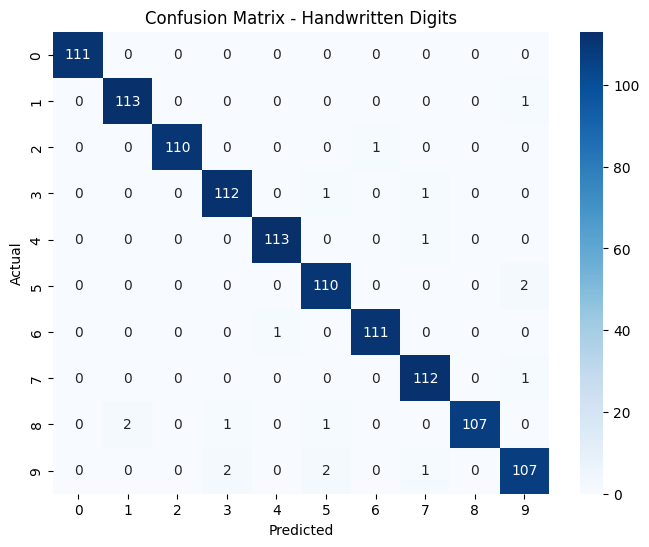


--- Generating Training & Loss Curves ---


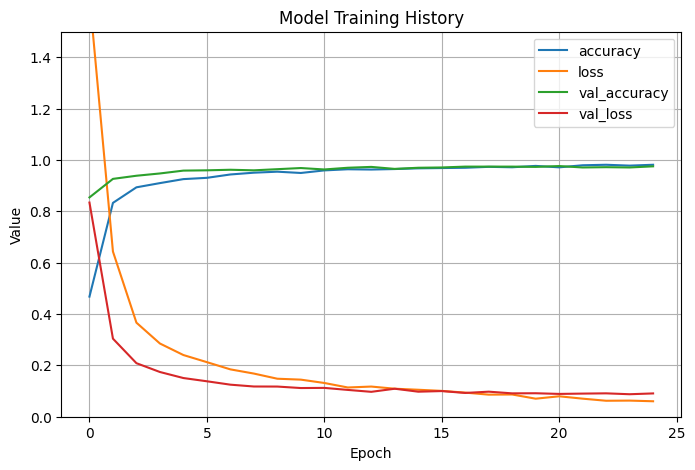


--- Generating ROC/AUC Curves (One-vs-Rest) ---


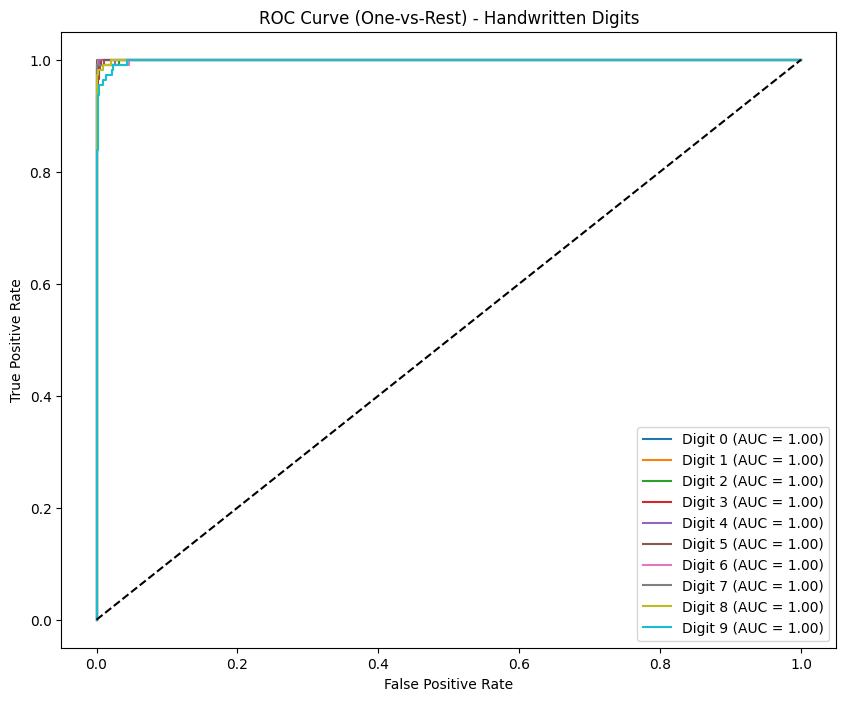

In [24]:
!pip install ucimlrepo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import from ucimlrepo
from ucimlrepo import fetch_ucirepo

# Import from Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_curve, auc
)

# Import from TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# --- 1. Load and Prepare Data (Handwritten Digits, ID 80) ---
print("--- Loading Handwritten Digit Dataset ---")
optical = fetch_ucirepo(id=80)
X = optical.data.features
y = optical.data.targets
y = np.ravel(y) # Flatten y
n_classes = 10

# Binarize y for one-vs-rest ROC curve
y_bin = label_binarize(y, classes=list(range(n_classes)))

# Train-test split (using 80:20 as per assignment suggestion)
# We split X, y (for training/CM), and y_bin (for ROC) together
X_train, X_test, y_train, y_test, y_train_bin, y_test_bin = train_test_split(
    X, y, y_bin, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# One-hot encode target variable 'y' for Keras
y_train_cat = to_categorical(y_train, num_classes=n_classes)
y_test_cat = to_categorical(y_test, num_classes=n_classes)

print(f"X_train shape: {X_train.shape}, y_train_cat shape: {y_train_cat.shape}")


# --- 2. Build the ANN (MLP) Model ---
print("\n--- Building ANN Model ---")
model = Sequential([
    Dense(64, activation='relu', input_shape=(64,)),
    Dropout(0.2),  # Dropout for regularization
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(n_classes, activation='softmax') # Softmax for multi-class
])

# Compile the model
# You can tune learning rate here
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()


# --- 3. Train the Model ---
print("\n--- Training Model ---")
# We can tune Epoch size here
history = model.fit(
    X_train, y_train_cat,
    validation_split=0.2, # Use part of training data for validation
    epochs=25,
    batch_size=32,
    verbose=1
)


# --- 4. Evaluate the Model ---
print("\n--- Model Evaluation ---")
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1) # Get the class with highest probability

# Classification Report (Accuracy, Precision, Recall, F-score)
print("Classification Report:")
print(classification_report(y_test, y_pred))


# --- 5. Generate Confusion Matrix ---
print("\n--- Generating Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(n_classes), yticklabels=range(n_classes))
plt.title("Confusion Matrix - Handwritten Digits")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# --- 6. Generate Training & Loss Curves ---
print("\n--- Generating Training & Loss Curves ---")
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1.5) # Adjust y-axis if loss is high
plt.title("Model Training History")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.show()


# --- 7. Generate ROC/AUC Curves ---
print("\n--- Generating ROC/AUC Curves (One-vs-Rest) ---")
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Digit {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest) - Handwritten Digits")
plt.legend(loc="lower right")
plt.show()